
# 03. NLP Preprocessing and Tokenization Comparison

## Definitions
- **Tokenization**: split text into model units
- **Normalization**: canonicalize case/spacing/accent
- **Stop words**: high-frequency function words (optional filtering)

## Why compare tokenizers?
Different tokenizers change vocabulary size, OOV rate, sequence length, and model cost.


In [1]:

from pathlib import Path
import pandas as pd

from utils.data import prepare_combined_corpus
from utils.tokenization import (
    HuggingFaceBPETokenizerBackend,
    NLTKTokenizerBackend,
    RegexTokenizerBackend,
    SpacyTokenizerBackend,
    compare_tokenizer_outputs,
    normalize_text,
)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bundle = prepare_combined_corpus(
    project_root=PROJECT_ROOT,
    include_wikitext=True,
    wikitext_train_tokens=80_000,
    wikitext_val_tokens=10_000,
    wikitext_test_tokens=10_000,
)

sample_text = normalize_text(bundle.train_text[:200_000])

hf_backend = HuggingFaceBPETokenizerBackend(vocab_size=3000, min_frequency=2)
hf_backend.fit([sample_text])

summary = compare_tokenizer_outputs(
    text=sample_text,
    backends=[
        RegexTokenizerBackend(),
        NLTKTokenizerBackend(),
        SpacyTokenizerBackend(),
        hf_backend,
    ],
)

summary_df = pd.DataFrame(summary)
summary_df


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Building a Predictive Keyboard Model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,backend,token_count,unique_tokens,throughput_tokens_per_sec,sample_tokens
0,regex,39086,4801,6.200602e+06,the adventures of sherlock holmes arthur conan...
1,nltk,39301,4742,1.256613e+04,the adventures of sherlock holmes arthur conan...
2,spacy,39301,4742,2.014979e+04,the adventures of sherlock holmes arthur conan...
3,hf_bpe,44984,2759,4.329937e+05,the adventures of sherlock holmes ar thur con ...


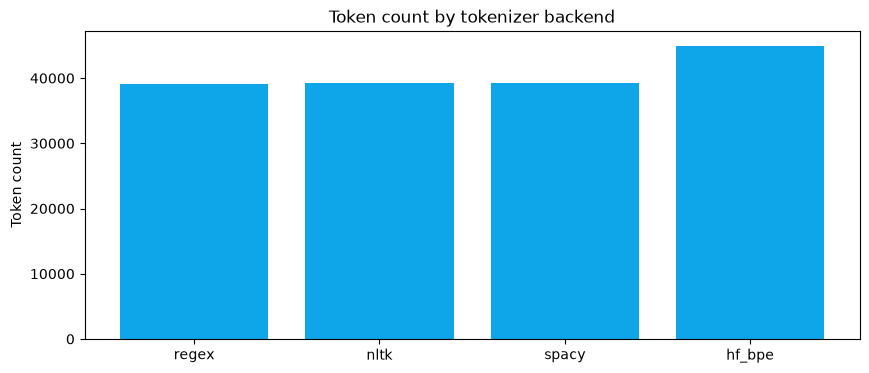

In [2]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(summary_df["backend"], summary_df["token_count"], color="#0ea5e9")
plt.title("Token count by tokenizer backend")
plt.ylabel("Token count")
plt.show()


In [3]:

# Word frequency analysis with NLTK tokenizer (baseline for later notebooks).
from collections import Counter

tokens = NLTKTokenizerBackend().tokenize(sample_text)
freq = Counter(tokens)

most_common_df = pd.DataFrame(freq.most_common(25), columns=["token", "count"])
most_common_df.head(10)


,token,count
0,the,2077
1,and,1172
2,i,1080
3,to,1035
4,of,1016
5,a,951
6,in,645
7,it,645
8,that,636
9,he,627



## Interpretation
- Tokenizer choice changes token granularity and throughput.
- We use NLTK word-level path for baseline model comparability.
- Subword BPE backend remains available for extension.
